In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

import aymansigmri as asm

In [2]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

onecoil_cart = kspace_cart_coils[0]
onecoil_cart.shape

(256, 256)

## Goal: Perform sliding window across one coil of the gridded data

In [5]:
import numpy as np

arr = np.arange(1, 2*6*6*6 + 1).reshape(2, 6, 6, 6).astype(np.complex64)
w = 3

In [21]:
def hankel(kspace, w):
    # kspace: (N_c, X, Y, Z)
    N_c = kspace.shape[0]
    N_x = kspace.shape[1] - w + 1
    N_y = kspace.shape[2] - w + 1
    N_z = kspace.shape[3] - w + 1
    data_matrix = []
    for c in range(N_c):
        onecoil_matrix = np.empty((w*w*w, N_x*N_y*N_z), dtype=np.complex64)
        col_index = 0
        for k in range(N_z):        # z outermost
            for i in range(N_y):
                for j in range(N_x):    # x innermost, matching your 2D ordering
                    mat = kspace[c, j:j+w, i:i+w, k:k+w]
                    onecoil_matrix[:, col_index] = mat.reshape(-1, order='F')
                    col_index += 1
        data_matrix.append(onecoil_matrix)
    return np.vstack(data_matrix), N_c, N_x, N_y, N_z


def hankel_H_averaged(data_matrix, n_coils, Nx, Ny, Nz, w=3):
    kspace = []
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1
    n_win_z = Nz - w + 1

    for c in range(n_coils):
        singlecoil = split_arr[c]
        transposed = singlecoil.T          # one row per window

        recon = np.zeros((Nx, Ny, Nz), dtype=np.complex64)
        counts = np.zeros((Nx, Ny, Nz), dtype=np.float32)

        for index in range(len(transposed)):
            win = transposed[index].reshape((w, w, w), order='F')

            # invert col_index = k*(n_win_y*n_win_x) + i*n_win_x + j
            j = index % n_win_x                      # x offset (innermost)
            i = (index // n_win_x) % n_win_y         # y offset
            k = index // (n_win_x * n_win_y)         # z offset (outermost)

            recon[j:j+w, i:i+w, k:k+w] += win
            counts[j:j+w, i:i+w, k:k+w] += 1

        kspace.append(recon / counts)
    return np.array(kspace)

In [11]:
data, N_c, N_x, N_y, N_z = hankel(arr, w)


- currently indexing in the wrong direction
- going in 

/var/folders/lp/mmccs9596xb7321q5q75xnj00000gn/T/ipykernel_60781/76284365.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  v = int(data[r, c])


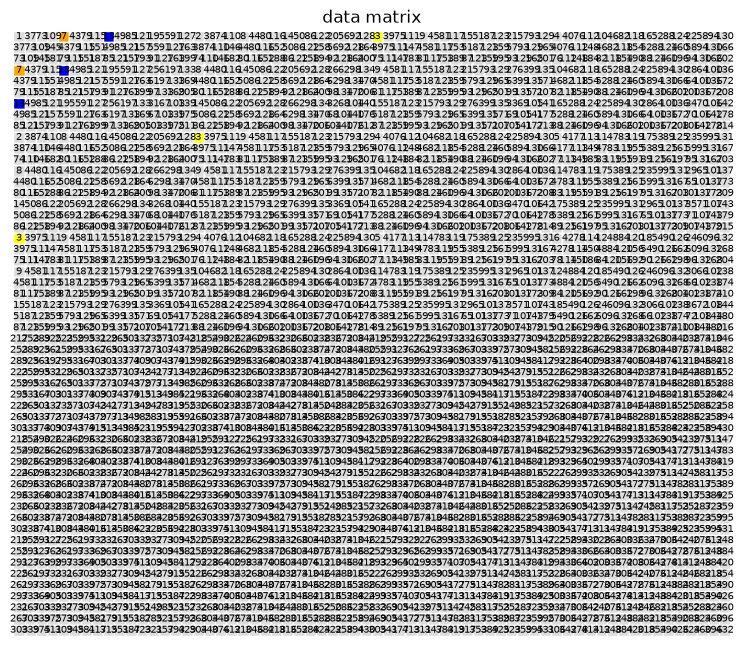

In [12]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


special = {3: 'yellow', 7: 'orange', 13: 'blue'}

fig, ax = plt.subplots(figsize=(20, 8))

ax.set_title('data matrix')
for r in range(data.shape[0]):
    for c in range(data.shape[1]):
        v = int(data[r, c])
        ax.add_patch(plt.Rectangle((c, -r), 1, 1, color=special.get(v, '#ddd'), ec='white'))
        ax.text(c+0.5, -r+0.5, str(v), ha='center', va='center', fontsize=7)
ax.set_xlim(0, data.shape[1])
#ax.set_ylim(-data.shape[0], 1)
ax.set_ylim(-data.shape[0], 1)
ax.set_aspect('equal')
ax.axis('off')

plt.show()


In [ ]:
data, N_c, N_x, N_y, N_z = hankel(arr, w)


In [18]:
def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def svd_recon(u, s_reduced, vh):
    return u @ np.diag(s_reduced) @ vh

In [19]:
U_data, sig_data, vh_data = sig_val_thresholding(data=data, zero_thresh=0)

recon = svd_recon(u=U_data, s_reduced=sig_data, vh=vh_data)

In [20]:
recovered = hankel_H_averaged(recon, N_c, 6, 6, 6, w)

recovered

array([[[[  1.000008 +0.j,   2.0000045+0.j,   3.0000038+0.j,
            4.000003 +0.j,   5.000001 +0.j,   6.000001 +0.j],
         [  7.0000067+0.j,   8.000004 +0.j,   9.000003 +0.j,
           10.000004 +0.j,  11.000002 +0.j,  12.000004 +0.j],
         [ 13.000006 +0.j,  14.000002 +0.j,  15.000002 +0.j,
           16.000002 +0.j,  17.000004 +0.j,  18.000004 +0.j],
         [ 19.000006 +0.j,  20.000002 +0.j,  21.000002 +0.j,
           22.000002 +0.j,  23.       +0.j,  24.000006 +0.j],
         [ 25.000004 +0.j,  26.000002 +0.j,  27.000006 +0.j,
           28.       +0.j,  29.       +0.j,  30.       +0.j],
         [ 31.000006 +0.j,  32.       +0.j,  33.       +0.j,
           34.       +0.j,  35.       +0.j,  36.00001  +0.j]],

        [[ 37.000008 +0.j,  38.       +0.j,  39.000008 +0.j,
           40.       +0.j,  41.000004 +0.j,  42.000004 +0.j],
         [ 43.000008 +0.j,  44.       +0.j,  45.       +0.j,
           46.       +0.j,  47.000004 +0.j,  48.000004 +0.j],
         [ 49.